In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
import os

files = ['datafile.csv', 'datafile (1).csv', 'datafile (2).csv', 'datafile (3).csv', 'produce.csv']

for f in files:
    path = f'd:/Agriculture_Crop_Project/data/Project4_Ag_Prediction of Agriculture Crop Production In India/{f}'
    try:
        df_temp = pd.read_csv(path)
        print(f"📄 {f} → Shape: {df_temp.shape} | Columns: {df_temp.columns.tolist()}")
        print()
    except Exception as e:
        print(f"❌ {f} → Error: {e}")
        print()

📄 datafile.csv → Shape: (13, 9) | Columns: ['Crop', '2004-05', '2005-06', '2006-07', '2007-08', '2008-09', '2009-10', '2010-11', '2011-12']

📄 datafile (1).csv → Shape: (49, 6) | Columns: ['Crop', 'State', 'Cost of Cultivation (`/Hectare) A2+FL', 'Cost of Cultivation (`/Hectare) C2', 'Cost of Production (`/Quintal) C2', 'Yield (Quintal/ Hectare) ']

📄 datafile (2).csv → Shape: (55, 16) | Columns: ['Crop             ', 'Production 2006-07', 'Production 2007-08', 'Production 2008-09', 'Production 2009-10', 'Production 2010-11', 'Area 2006-07', 'Area 2007-08', 'Area 2008-09', 'Area 2009-10', 'Area 2010-11', 'Yield 2006-07', 'Yield 2007-08', 'Yield 2008-09', 'Yield 2009-10', 'Yield 2010-11']

📄 datafile (3).csv → Shape: (78, 5) | Columns: ['Crop', 'Variety', 'Season/ duration in days', 'Recommended Zone', 'Unnamed: 4']

📄 produce.csv → Shape: (429, 25) | Columns: ['Particulars', 'Frequency', 'Unit', ' 3-1993', ' 3-1994', ' 3-1995', ' 3-1996', ' 3-1997', ' 3-1998', ' 3-1999', ' 3-2000', ' 3

In [13]:
df = pd.read_csv('d:/Agriculture_Crop_Project/data/Project4_Ag_Prediction of Agriculture Crop Production In India/datafile (2).csv')

df.columns = df.columns.str.strip()

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (55, 16)
Columns: ['Crop', 'Production 2006-07', 'Production 2007-08', 'Production 2008-09', 'Production 2009-10', 'Production 2010-11', 'Area 2006-07', 'Area 2007-08', 'Area 2008-09', 'Area 2009-10', 'Area 2010-11', 'Yield 2006-07', 'Yield 2007-08', 'Yield 2008-09', 'Yield 2009-10', 'Yield 2010-11']


,Crop,Production 2006-07,Production 2007-08,Production 2008-09,Production 2009-10,Production 2010-11,Area 2006-07,Area 2007-08,Area 2008-09,Area 2009-10,Area 2010-11,Yield 2006-07,Yield 2007-08,Yield 2008-09,Yield 2009-10,Yield 2010-11
0,Total Foodgrains,158.8,168.6,171.3,159.4,178.9,128.5,128.8,127.6,126.0,131.7,123.6,130.9,134.3,126.5,135.9
1,Rice,200.8,207.9,213.3,191.6,206.4,168.5,168.9,175.1,161.2,164.8,119.2,123.1,121.8,118.9,125.2
2,Wheat,131.6,136.4,140.1,140.3,150.8,115.0,115.2,114.0,116.9,119.5,114.4,118.4,122.8,120.0,126.3
3,Jowar,124.3,137.8,126.0,116.5,121.8,120.7,110.6,107.3,111.0,105.2,103.0,124.6,117.4,105.0,115.8
4,Bajra,136.4,161.5,143.9,105.4,167.9,94.5,95.1,87.0,88.5,95.6,144.3,169.7,165.4,119.0,175.8


In [6]:
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape: (55, 16)

Missing Values:
Crop                  0
Production 2006-07    0
Production 2007-08    0
Production 2008-09    0
Production 2009-10    0
Production 2010-11    0
Area 2006-07          0
Area 2007-08          0
Area 2008-09          0
Area 2009-10          0
Area 2010-11          0
Yield 2006-07         0
Yield 2007-08         0
Yield 2008-09         0
Yield 2009-10         0
Yield 2010-11         0
dtype: int64

Basic Statistics:


,Production 2006-07,Production 2007-08,Production 2008-09,Production 2009-10,Production 2010-11,Area 2006-07,Area 2007-08,Area 2008-09,Area 2009-10,Area 2010-11,Yield 2006-07,Yield 2007-08,Yield 2008-09,Yield 2009-10,Yield 2010-11
count,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000
mean,168.698182,182.629091,179.952727,173.749091,210.181818,116.025455,118.403636,120.530909,118.203636,127.216364,146.829091,153.774545,149.476364,147.427273,164.570909
std,179.503163,199.671545,187.409253,184.231322,232.535985,37.990960,41.287797,44.460177,44.976615,54.842653,144.836331,153.243102,141.412539,143.963743,160.925948
min,53.900000,54.400000,50.000000,42.900000,42.100000,47.900000,47.400000,43.600000,37.500000,36.100000,86.000000,75.300000,72.700000,80.700000,80.800000
25%,124.500000,122.200000,116.050000,105.350000,126.900000,92.550000,93.300000,93.200000,88.650000,90.650000,106.800000,116.800000,110.950000,108.300000,121.050000
50%,142.700000,160.100000,156.500000,140.300000,169.000000,120.700000,121.700000,121.900000,120.900000,129.400000,118.700000,124.500000,123.600000,122.100000,138.900000
75%,184.300000,200.100000,188.550000,197.050000,217.350000,131.050000,135.800000,136.250000,134.800000,147.950000,137.600000,154.400000,148.500000,142.800000,168.850000
max,1427.700000,1571.500000,1463.000000,1430.300000,1790.600000,222.700000,241.600000,254.500000,260.300000,314.700000,1176.600000,1247.700000,1156.800000,1172.100000,1310.800000


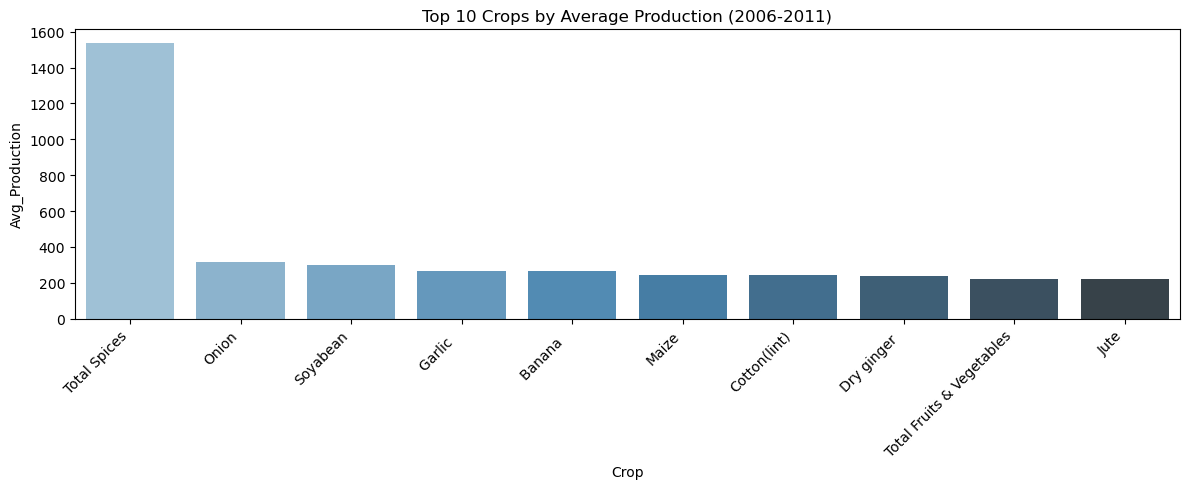

Chart saved!


In [14]:
prod_cols = ['Production 2006-07', 'Production 2007-08', 'Production 2008-09', 
             'Production 2009-10', 'Production 2010-11']

df['Avg_Production'] = df[prod_cols].mean(axis=1)

top10 = df[['Crop', 'Avg_Production']].sort_values('Avg_Production', ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=top10, x='Crop', y='Avg_Production', palette='Blues_d')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Crops by Average Production (2006-2011)')
plt.tight_layout()
plt.savefig('d:/Agriculture_Crop_Project/output/top_crops.png')
plt.show()
print("Chart saved!")

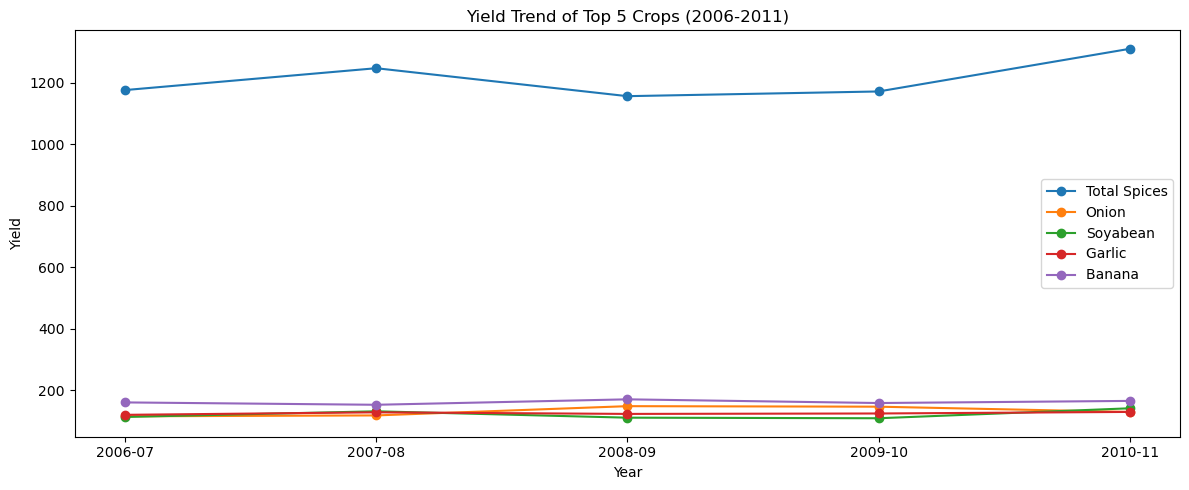

Chart saved!


In [15]:
yield_cols = ['Yield 2006-07', 'Yield 2007-08', 'Yield 2008-09', 'Yield 2009-10', 'Yield 2010-11']
years = ['2006-07', '2007-08', '2008-09', '2009-10', '2010-11']

top5_crops = df.nlargest(5, 'Avg_Production')['Crop'].tolist()

plt.figure(figsize=(12, 5))
for crop in top5_crops:
    values = df[df['Crop'] == crop][yield_cols].values.flatten()
    plt.plot(years, values, marker='o', label=crop)

plt.title('Yield Trend of Top 5 Crops (2006-2011)')
plt.xlabel('Year')
plt.ylabel('Yield')
plt.legend()
plt.tight_layout()
plt.savefig('d:/Agriculture_Crop_Project/output/yield_trend.png')
plt.show()
print("Chart saved!")

In [16]:
df_ml = df.copy()

df_ml = df_ml.drop(columns=['Avg_Production'])

df_melted = pd.melt(df_ml, id_vars=['Crop'], 
                    value_vars=prod_cols,
                    var_name='Year', value_name='Production')

df_melted['Year'] = df_melted['Year'].str.extract(r'(\d{4})').astype(int)

le = LabelEncoder()
df_melted['Crop_Encoded'] = le.fit_transform(df_melted['Crop'])

print("Shape after reshape:", df_melted.shape)
print(df_melted.head(10))

Shape after reshape: (275, 4)
               Crop  Year  Production  Crop_Encoded
0  Total Foodgrains  2006       158.8            47
1              Rice  2006       200.8            33
2             Wheat  2006       131.6            54
3             Jowar  2006       124.3            20
4             Bajra  2006       136.4             2
5             Maize  2006       198.8            24
6              Ragi  2006        56.1            31
7     Small millets  2006        53.9            38
8            Barley  2006        88.1             4
9    Coarse Cereals  2006       138.5             9


In [17]:
X = df_melted[['Crop_Encoded', 'Year']]
y = df_melted['Production']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("\nModel trained successfully! ✅")

Train size: (220, 2)
Test size: (55, 2)

Model trained successfully! ✅


Model Evaluation Results:
MAE  : 29.76
RMSE : 38.72
R2   : 0.5661


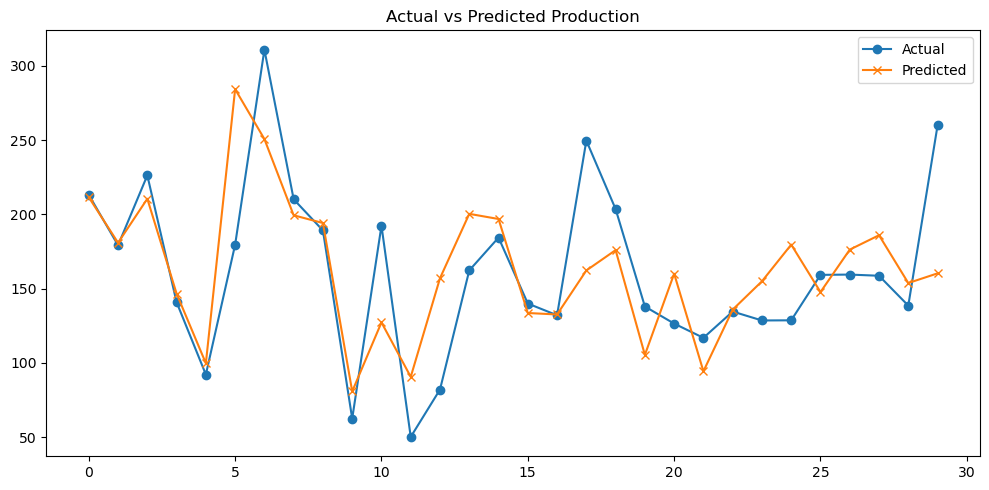

Chart saved!


In [18]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Model Evaluation Results:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:30], label='Actual', marker='o')
plt.plot(y_pred[:30], label='Predicted', marker='x')
plt.title('Actual vs Predicted Production')
plt.legend()
plt.tight_layout()
plt.savefig('d:/Agriculture_Crop_Project/output/actual_vs_predicted.png')
plt.show()
print("Chart saved!")

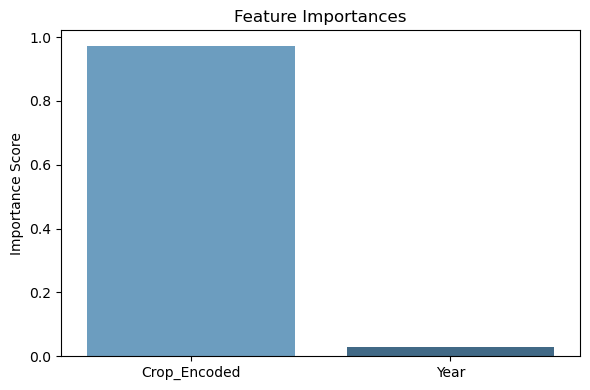

✅ Feature importance chart saved!
✅ Predictions CSV saved!

🎉 PROJECT 4 COMPLETE!


In [19]:
feat_imp = pd.Series(model.feature_importances_, index=['Crop_Encoded', 'Year'])

plt.figure(figsize=(6, 4))
sns.barplot(x=feat_imp.index, y=feat_imp.values, palette='Blues_d')
plt.title('Feature Importances')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('d:/Agriculture_Crop_Project/output/feature_importance.png')
plt.show()


results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred.round(2)
})
results.to_csv('d:/Agriculture_Crop_Project/output/predictions.csv', index=False)

print("✅ Feature importance chart saved!")
print("✅ Predictions CSV saved!")
print("\n🎉 PROJECT 4 COMPLETE!")